# Column 05 - Pair spread decomposition and stat-arb

This notebook rewrites pairs trading around spread structure: rolling hedge ratio, spread trend drift, cycle timing and residual deviation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from quant_trading.data import load_bundled_real_ohlcv_panel, ohlcv_audit_report
from quant_trading.strategy_pairs import (
    walkforward_pair_spread_features, pair_diagnostics, pair_feature_snapshot,
    make_classic_pair_weight_grid, make_detime_pair_weight_grid,
)
from quant_trading.validation import turnover_report, compare_weight_strategies

## 1. Load real offline market data

In [2]:
tickers = ["AUDUSD=X", "NZDUSD=X", "EURUSD=X", "GBPUSD=X"]
pairs = [("AUDUSD=X", "NZDUSD=X"), ("EURUSD=X", "GBPUSD=X")]
ohlcv = load_bundled_real_ohlcv_panel(tickers, min_observations=120)
ohlcv = {field: table.tail(520).copy() for field, table in ohlcv.items()}
prices = ohlcv["Close"]
ohlcv_audit_report(ohlcv)

,ticker,first_timestamp,last_timestamp,observations,close_missing_ratio,volume_missing_ratio,zero_volume_ratio,min_close,max_close,median_volume
0,AUDUSD=X,2016-01-04,2018-01-02,520,0.0,0.0,1.0,0.686106,0.805802,0.0
1,NZDUSD=X,2016-01-04,2018-01-02,520,0.0,0.0,1.0,0.640287,0.752570,0.0
2,EURUSD=X,2016-01-04,2018-01-02,520,0.0,0.0,1.0,1.039047,1.202906,0.0
3,GBPUSD=X,2016-01-04,2018-01-02,520,0.0,0.0,1.0,1.203935,1.478940,0.0


## 2. Build walk-forward spread decomposition features

In [3]:
spread_features, spread_panel, beta_panel, pair_specs = walkforward_pair_spread_features(
    prices, pairs, hedge_window=90, method="STL", period=42, train_window=180, step=252, z_window=42
)
spread_panel.tail()

,AUDUSD=X__NZDUSD=X,EURUSD=X__GBPUSD=X
Date,,
2017-12-27,-0.100258,0.060945
2017-12-28,-0.094383,0.064674
2017-12-29,-0.090705,0.064913
2018-01-01,-0.090874,0.066027
2018-01-02,-0.092184,0.076336


In [4]:
pair_diagnostics(prices, pair_specs, hedge_window=90)

,pair,date,spread,beta,pair_corr_120,spread_trend_slope,spread_cycle_slope,spread_residual_z,spread_residual_abs_z,volume_liquidity_ok
0,AUDUSD=X/NZDUSD=X,2018-01-02,-0.092184,0.453700,0.632244,-0.000730,-0.000847,-0.929979,0.929979,True
1,EURUSD=X/GBPUSD=X,2018-01-02,0.076336,0.355382,0.446730,0.000247,-0.000303,0.614364,0.614364,True


In [5]:
snapshot = pair_feature_snapshot(spread_features, tail=2)
snapshot.query("feature in ['trend_slope', 'cycle_slope', 'residual_z', 'residual_abs_z']").tail(16)

,date,pair,feature,value
12,2018-01-01,AUDUSD=X__NZDUSD=X,residual_abs_z,0.475670
13,2018-01-01,EURUSD=X__GBPUSD=X,residual_abs_z,0.055528
14,2018-01-02,AUDUSD=X__NZDUSD=X,residual_abs_z,0.475670
15,2018-01-02,EURUSD=X__GBPUSD=X,residual_abs_z,0.055528
28,2018-01-01,AUDUSD=X__NZDUSD=X,trend_slope,0.000559
29,2018-01-01,EURUSD=X__GBPUSD=X,trend_slope,0.000787
30,2018-01-02,AUDUSD=X__NZDUSD=X,trend_slope,0.000559
31,2018-01-02,EURUSD=X__GBPUSD=X,trend_slope,0.000787
48,2018-01-01,AUDUSD=X__NZDUSD=X,residual_z,-0.475670
49,2018-01-01,EURUSD=X__GBPUSD=X,residual_z,-0.055528


## 3. Backtest classical baselines and De-Time rewrites

In [6]:
classic_weights = make_classic_pair_weight_grid(prices, pairs=pairs, lookback=90)
detime_weights = make_detime_pair_weight_grid(prices, pair_specs, spread_features, spread_panel=spread_panel, beta_panel=beta_panel)
all_weights = {**classic_weights, **detime_weights}
comparison, results = compare_weight_strategies(prices, all_weights, fee_bps=1.0, slippage_bps=2.0)
comparison.insert(0, "strategy_group", ["detime_pair" if str(idx).startswith("detime") else "classical_pair" for idx in comparison.index])
comparison[["strategy_group", "cagr", "sharpe", "max_drawdown", "average_turnover"]].round(4)

,strategy_group,cagr,sharpe,max_drawdown,average_turnover
strategy,,,,,
classic_pair_ratio_zscore_120,classical_pair,0.0215,0.6203,-0.0338,0.0635
detime_spread_trend_drift_blocker,detime_pair,0.0130,0.4671,-0.0275,0.0058
detime_spread_residual_z,detime_pair,0.0000,0.0000,0.0000,0.0000
detime_spread_cycle_timed,detime_pair,0.0000,0.0000,0.0000,0.0000
classic_pair_spread_zscore_120,classical_pair,-0.0160,-0.4592,-0.0596,0.0519
classic_pair_corr_filtered_zscore,classical_pair,-0.0169,-0.5181,-0.0563,0.0473


## 4. Visualize spread structure and after-cost equity

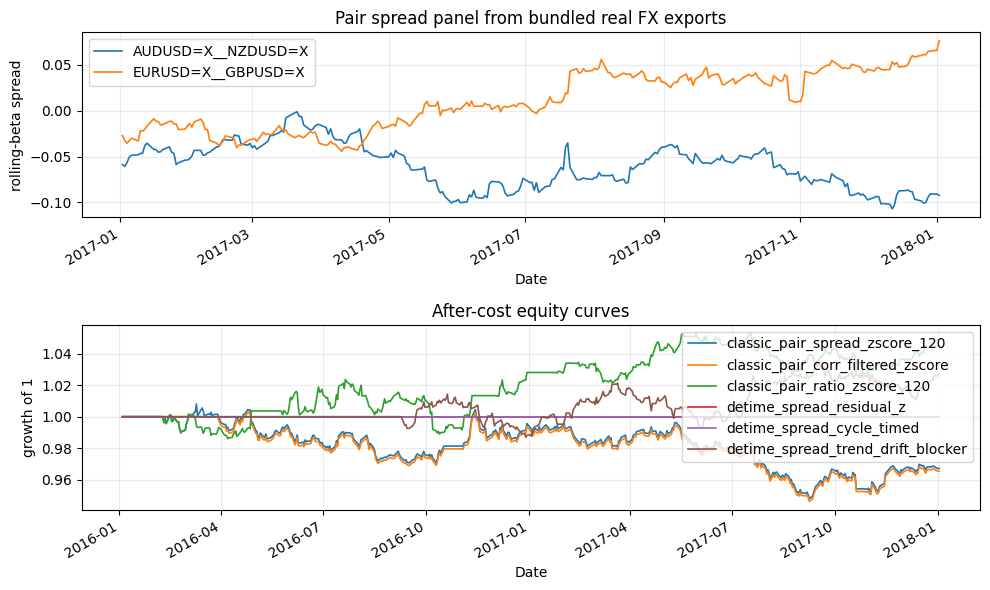

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)
spread_panel.tail(260).plot(ax=axes[0], linewidth=1.2)
axes[0].set_title("Pair spread panel from bundled real FX exports")
axes[0].set_ylabel("rolling-beta spread")

equity_curves = pd.DataFrame({name: result.equity for name, result in results.items()})
equity_curves.plot(ax=axes[1], linewidth=1.2)
axes[1].set_title("After-cost equity curves")
axes[1].set_ylabel("growth of 1")
for ax in axes:
    ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

In [8]:
turnover_report(all_weights).round(4)

,average_turnover,median_turnover,max_turnover,average_gross_exposure
strategy,,,,
classic_pair_spread_zscore_120,0.0519,0.0035,2.0,0.9135
classic_pair_corr_filtered_zscore,0.0473,0.0032,2.0,0.8481
classic_pair_ratio_zscore_120,0.0635,0.0000,1.0,0.8019
detime_spread_residual_z,0.0000,0.0000,0.0,0.0000
detime_spread_cycle_timed,0.0000,0.0000,0.0,0.0000
detime_spread_trend_drift_blocker,0.0058,0.0012,1.0,0.6558


## 4. Live-data extension

Run `run_column_05_pairs_spread_decomposition.py` without `--use-bundled-sample` and pass pairs such as `KO:PEP`, `XOM:CVX`, `MA:V`, or `SPY:QQQ`.